In [ ]:
import requests
import pandas as pd
import os
from time import sleep

def extrair_ifdata_robusto(pasta_destino):
    os.makedirs(pasta_destino, exist_ok=True)
    
    tipo_inst = 1
    relatorios = {
        "1": "Resumo", 
        "2": "Ativo", 
        "3": "Passivo", 
        "4": "Resultado"
    }
    
    anos = range(2014, 2025)
    trimestres = ["03", "06", "09", "12"]
    print(f"Iniciando Extração de Alta Performance: {os.path.abspath(pasta_destino)}")
    print("-" * 60)
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)"})
    for ano in anos:
        for tri in trimestres:
            data_ref = int(f"{ano}{tri}")
            
            for cod_rel, nome_rel in relatorios.items():
                nome_arquivo = f"IFDATA_{data_ref}_{nome_rel}.csv"
                caminho_completo = os.path.join(pasta_destino, nome_arquivo)

                if os.path.exists(caminho_completo):
                    print(f"[PULANDO] {nome_arquivo} já existe.")
                    continue
                
                url = (
                    f"https://olinda.bcb.gov.br/olinda/servico/IFDATA/versao/v1/odata/"
                    f"IfDataValores(AnoMes=@AnoMes,TipoInstituicao=@TipoInstituicao,Relatorio=@Relatorio)"
                    f"?@AnoMes={data_ref}&@TipoInstituicao={tipo_inst}&@Relatorio='{cod_rel}'&$format=json"
                )
                
                sucesso = False
                
                for tentativa in range(1, 4):
                    try:
                        resposta = session.get(url, timeout=120)
                        
                        if resposta.status_code == 200:
                            dados = resposta.json().get('value', [])
                            if dados:
                                df = pd.DataFrame(dados)
                                df.to_csv(caminho_completo, index=False, sep=';', encoding='utf-8-sig')
                                print(f"[OK] Sucesso: {data_ref} - {nome_rel} ({len(df)} linhas)")
                            else:
                                print(f"[-] Vazio: {data_ref} - {nome_rel}")
                                
                            sucesso = True
                            break 
                            
                        else:
                            print(f"[Erro {resposta.status_code}] Tentativa {tentativa}/3 para {nome_rel}_{data_ref}")
                            sleep(3) 
                            
                    except requests.exceptions.ReadTimeout:
                        print(f"[Timeout] BCB lento na tentativa {tentativa}/3 ({nome_rel}_{data_ref}). Retentando...")
                        sleep(5)
                    except requests.exceptions.RequestException as e:
                        print(f"[Falha de Rede] Tentativa {tentativa}/3: {e}")
                        sleep(5)
                
                if not sucesso:
                    print(f"[DESISTÊNCIA] Não foi possível baixar {nome_arquivo}. Tente em outro horário.")
                sleep(0.5)

    print("\nProcesso concluído!")
extrair_ifdata_robusto('./dados_bcb_olinda')

Iniciando Extração de Alta Performance: /home/inovar-para-pessoas-negras/Área de trabalho/gustavo/bank-distress-foretoken/dados_bcb_olinda
------------------------------------------------------------
[-] Vazio: 200503 - Resumo
[-] Vazio: 200503 - Ativo
[-] Vazio: 200503 - Passivo
[-] Vazio: 200503 - Resultado


KeyboardInterrupt: 

In [2]:
import pandas as pd
import glob
import os

def processar_e_unir_ifdata(pasta_dados):
    print("Iniciando a leitura de todos os arquivos...")
    
    arquivos = glob.glob(os.path.join(pasta_dados, "IFDATA_*.csv"))
    
    if not arquivos:
        print("Nenhum arquivo encontrado na pasta.")
        return None

    lista_dfs = []
    for arquivo in arquivos:
        print(f"Lendo: {os.path.basename(arquivo)}")
        df = pd.read_csv(arquivo, sep=';', dtype={'CodInst': str, 'AnoMes': str})
        lista_dfs.append(df)

    print("\nEmpilhando os dados (Concatenando)...")
    df_completo = pd.concat(lista_dfs, ignore_index=True)
    print("Limpando e estruturando os nomes das contas contábeis...")
    if 'NomeColuna' in df_completo.columns:
        df_completo['NomeColuna'] = df_completo['NomeColuna'].str.replace('\n', ' ', regex=False)
        df_completo['NomeColuna'] = df_completo['NomeColuna'].str.replace(r'\s+', ' ', regex=True).str.strip()
        
        if 'NomeRelatorio' in df_completo.columns:
            df_completo['NomeColuna'] = df_completo['NomeRelatorio'] + " - " + df_completo['NomeColuna']

    print("Girando a tabela para o formato de Inteligência Artificial (Pivot)...")
    df_mestre = df_completo.pivot_table(
        index=['CodInst', 'AnoMes'], 
        columns='NomeColuna', 
        values='Saldo', 
        aggfunc='first'
    ).reset_index()
    df_mestre = df_mestre.fillna(0)
    caminho_saida = os.path.join(pasta_dados, "DATASET_MESTRE_IA.csv")
    df_mestre.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 60)
    print(f"SUCESSO! Tabela final criada com {df_mestre.shape[0]} registros e {df_mestre.shape[1]} colunas contábeis.")
    print(f"Arquivo salvo em: {caminho_saida}")
    
    return df_mestre
dataset_final = processar_e_unir_ifdata('./dados_bcb_olinda')

Iniciando a leitura de todos os arquivos...
Lendo: IFDATA_202103_Passivo.csv
Lendo: IFDATA_202212_Resultado.csv
Lendo: IFDATA_201903_Ativo.csv
Lendo: IFDATA_202012_Resumo.csv
Lendo: IFDATA_202403_Resumo.csv
Lendo: IFDATA_201506_Ativo.csv
Lendo: IFDATA_202403_Resultado.csv
Lendo: IFDATA_202312_Resultado.csv
Lendo: IFDATA_202406_Passivo.csv
Lendo: IFDATA_202309_Resumo.csv
Lendo: IFDATA_201909_Ativo.csv
Lendo: IFDATA_201603_Passivo.csv
Lendo: IFDATA_201406_Resumo.csv
Lendo: IFDATA_201809_Resultado.csv
Lendo: IFDATA_202006_Resultado.csv
Lendo: IFDATA_201809_Resumo.csv
Lendo: IFDATA_202206_Resultado.csv
Lendo: IFDATA_202409_Ativo.csv
Lendo: IFDATA_201709_Ativo.csv
Lendo: IFDATA_201503_Ativo.csv
Lendo: IFDATA_201909_Resumo.csv
Lendo: IFDATA_201612_Ativo.csv
Lendo: IFDATA_201709_Passivo.csv
Lendo: IFDATA_202412_Ativo.csv
Lendo: IFDATA_201512_Resultado.csv
Lendo: IFDATA_202106_Ativo.csv
Lendo: IFDATA_202103_Ativo.csv
Lendo: IFDATA_202409_Passivo.csv
Lendo: IFDATA_201412_Passivo.csv
Lendo: IFDA

KeyboardInterrupt: 

In [10]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

# 1. Configurações
pasta_dados = "." # Pasta onde estão os arquivos CSV
arquivos = glob.glob(f"{pasta_dados}/IFDATA_*_*.csv")

print(f"Lendo {len(arquivos)} arquivos...")

df_list = []

# 2. Leitura e Padronização Inicial
for arquivo in arquivos:
    df_temp = pd.read_csv(arquivo, sep=';', dtype=str)
    
    # Padroniza o nome das colunas para minúsculo
    df_temp.columns = [col.lower().strip() for col in df_temp.columns]
    
    # Renomeia colunas do Olinda para o padrão do bacenR
    renomeio = {
        'codinst': 'cod_inst',
        'nomecoluna': 'nome_coluna',
        'anomes': 'ano_mes'
    }
    df_temp.rename(columns=renomeio, inplace=True)
    
    # Mantém apenas as colunas que importam para a GNN para economizar memória
    colunas_uteis = ['cod_inst', 'ano_mes', 'nome_coluna', 'saldo']
    df_temp = df_temp[[c for c in colunas_uteis if c in df_temp.columns]]
    
    df_list.append(df_temp)

# Junta tudo num tabelão gigante
df_longo = pd.concat(df_list, ignore_index=True)

# 3. Limpeza dos Dados (MUDANÇA APLICADA AQUI)
# Remove tudo o que vem depois da quebra de linha (ex: "\n(j) = (g) + (h)") para unificar as épocas
df_longo['nome_coluna'] = df_longo['nome_coluna'].astype(str).apply(lambda x: x.split('\n')[0].strip())
# Remove possíveis aspas duplas presas na string e espaços múltiplos
df_longo['nome_coluna'] = df_longo['nome_coluna'].str.replace('"', '', regex=False).str.replace(' +', ' ', regex=True)

# Converte o Saldo para número
df_longo['saldo'] = df_longo['saldo'].astype(str).str.replace(',', '.', regex=False)
df_longo['saldo'] = pd.to_numeric(df_longo['saldo'], errors='coerce').fillna(0)

# 4. A Mágica do Pivot: Criação dos NODES (Nós)
print("Construindo matriz de features dos nós (Nodes)...")
df_nodes = df_longo.pivot_table(
    index=['cod_inst', 'ano_mes'], 
    columns='nome_coluna', 
    values='saldo', 
    aggfunc='sum'
).reset_index()

# Preenche valores vazios com 0
df_nodes = df_nodes.fillna(0)

# Salva os Nodes em CSV
df_nodes.to_csv("gnn_nodes_features.csv", index=False, sep=';')
print(f"✅ Arquivo de Nodes salvo com {df_nodes.shape[0]} registros e {df_nodes.shape[1]-2} features!")

# 5. Criação dos EDGES (Arestas / Conexões)
periodo_recente = df_nodes['ano_mes'].max()
df_nodes_periodo = df_nodes[df_nodes['ano_mes'] == periodo_recente].copy()

print(f"Construindo matriz de conexões (Edges) para o período {periodo_recente} baseada em similaridade (KNN)...")

# Isola só os valores financeiros para calcular a distância
features = df_nodes_periodo.drop(columns=['cod_inst', 'ano_mes'])
bancos_ids = df_nodes_periodo['cod_inst'].values

# Padroniza os dados (MUITO importante para GNN e KNN)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Encontra os 5 bancos mais similares para cada banco
knn = NearestNeighbors(n_neighbors=6, metric='cosine')
knn.fit(features_scaled)
distancias, indices = knn.kneighbors(features_scaled)

edges = []
for i in range(len(bancos_ids)):
    banco_origem = bancos_ids[i]
    for j in range(1, 6):
        banco_destino = bancos_ids[indices[i][j]]
        peso = 1 - distancias[i][j] 
        
        edges.append({
            'source': banco_origem,
            'target': banco_destino,
            'weight': round(peso, 4)
        })

df_edges = pd.DataFrame(edges)
df_edges.to_csv("gnn_edges_index.csv", index=False, sep=';')
print(f"✅ Arquivo de Edges salvo com {len(df_edges)} conexões!")

Lendo 0 arquivos...


ValueError: No objects to concatenate

Etapa dois: Nós dos Grafo

In [11]:
import pandas as pd
import numpy as np
import glob
import os
from sklearn.preprocessing import StandardScaler

def criar_matriz_gnn_robusta(pasta_dados):
    print("1. A iniciar o Pipeline de Processamento para GNN...")
    todos_ficheiros = glob.glob(os.path.join(pasta_dados, "IFDATA_*.csv"))
    
    if not todos_ficheiros:
        print("Erro: Nenhum ficheiro encontrado. Verifique o nome da pasta!")
        return
    
    lista_dfs = []

    print(f"2. A ler e a limpar {len(todos_ficheiros)} ficheiros temporais...")
    for ficheiro in todos_ficheiros:
        try:
            nome_base = os.path.basename(ficheiro).replace(".csv", "")
            partes = nome_base.split("_")
            if len(partes) < 3: continue
                
            relatorio = partes[2] 
            df = pd.read_csv(ficheiro, sep=';', dtype=str)
            df.columns = [c.lower() for c in df.columns]
            mapeamento = {
                'anomes': 'Data',
                'data': 'Data',
                'cnpjinst': 'CnpjInst',
                'codinst': 'CnpjInst',       
                'nomeinst': 'NomeInst',
                'item': 'Item',
                'descricaocoluna': 'Item',    
                'valor': 'valor',
                'saldo': 'valor'             
            }
            df = df.rename(columns=mapeamento)
            if 'NomeInst' not in df.columns:
                df['NomeInst'] = 'Desconhecido'
            if 'Item' in df.columns and 'valor' in df.columns and 'CnpjInst' in df.columns:
                df['Item_Completo'] = relatorio + "_" + df['Item'].str.strip()
                df['valor'] = df['valor'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False)
                df['valor'] = pd.to_numeric(df['valor'], errors='coerce') 
                lista_dfs.append(df[['Data', 'CnpjInst', 'NomeInst', 'Item_Completo', 'valor']])
            else:
                print(f" [!] Estranho: Ficheiro {nome_base} ainda falha. Colunas finais: {list(df.columns)}")
                
        except Exception as e:
            print(f" [!] Erro ao processar {ficheiro}: {e}")

    if not lista_dfs:
        print("\n[ERRO FATAL] Nenhum dado pôde ser extraído.")
        return

    df_empilhado = pd.concat(lista_dfs, ignore_index=True)
    
    print("3. A remover duplicatas e anomalias do BCB...")
    df_empilhado = df_empilhado.drop_duplicates(subset=['Data', 'CnpjInst', 'Item_Completo'], keep='last')

    print("4. A fundir a Visão de Contexto Geral (Nós do Grafo)...")
    df_mestre = df_empilhado.pivot(
        index=['Data', 'CnpjInst', 'NomeInst'], 
        columns='Item_Completo', 
        values='valor'
    ).reset_index()

    print("5. A aplicar Filtro de Esparsidade (Remoção de colunas vazias)...")
    limite_nulos = len(df_mestre) * 0.60 
    df_mestre = df_mestre.dropna(thresh=limite_nulos, axis=1)
    df_mestre = df_mestre.fillna(0)
    
    print("6. A normalizar as Escalas Matemáticas (StandardScaler)...")
    cols_identificadoras = ['Data', 'CnpjInst', 'NomeInst']
    cols_numericas = [col for col in df_mestre.columns if col not in cols_identificadoras]
    
    scaler = StandardScaler()
    df_mestre[cols_numericas] = scaler.fit_transform(df_mestre[cols_numericas])

    caminho_saida = os.path.join(pasta_dados, "NODE_FEATURES_GNN_2014_2024.csv")
    df_mestre.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 60)
    print("SUCESSO ABSOLUTO! Etapa 2 Concluída.")
    print(f"Novo ficheiro guardado em: {caminho_saida}")

# Executar
criar_matriz_gnn_robusta('./dados_bcb_olinda')

1. A iniciar o Pipeline de Processamento para GNN...
2. A ler e a limpar 400 ficheiros temporais...
 [!] Estranho: Ficheiro IFDATA_201212_Resultado ainda falha. Colunas finais: ['tipo_instituicao', 'cod_inst', 'ano_mes', 'nome_relatorio', 'numero_relatorio', 'grupo', 'conta', 'nome_coluna', 'descricao_coluna', 'valor', 'NomeInst']
 [!] Estranho: Ficheiro IFDATA_200806_Passivo ainda falha. Colunas finais: ['tipo_instituicao', 'cod_inst', 'ano_mes', 'nome_relatorio', 'numero_relatorio', 'grupo', 'conta', 'nome_coluna', 'descricao_coluna', 'valor', 'NomeInst']
 [!] Estranho: Ficheiro IFDATA_201103_Resumo ainda falha. Colunas finais: ['tipo_instituicao', 'cod_inst', 'ano_mes', 'nome_relatorio', 'numero_relatorio', 'grupo', 'conta', 'nome_coluna', 'descricao_coluna', 'valor', 'NomeInst']
 [!] Estranho: Ficheiro IFDATA_200706_Passivo ainda falha. Colunas finais: ['tipo_instituicao', 'cod_inst', 'ano_mes', 'nome_relatorio', 'numero_relatorio', 'grupo', 'conta', 'nome_coluna', 'descricao_colun

Etapa 3: A Teia de Contágio (Arestas/Edges)

In [ ]:
import pandas as pd
import numpy as np
import glob
import os

# 1. Configurações
pasta_dados = "dados_bcb_olinda" # Coloque o caminho da sua pasta aqui
arquivos = glob.glob(f"{pasta_dados}/IFDATA_*_*.csv")

print(f"A procurar na pasta: {os.path.abspath(pasta_dados)}")
print(f"Encontrados {len(arquivos)} ficheiros para processar...")

if len(arquivos) == 0:
    print("❌ ERRO: Nenhum ficheiro encontrado! Verifique se a variável 'pasta_dados' está correta.")
    exit()

df_list = []

# 2. Leitura e Padronização Inicial
for arquivo in arquivos:
    df_temp = pd.read_csv(arquivo, sep=';', dtype=str)
    
    # Padroniza o nome das colunas para minúsculo
    df_temp.columns = [col.lower().strip() for col in df_temp.columns]
    
    # Renomeia colunas do Olinda para o padrão do bacenR (unificando as épocas)
    renomeio = {
        'codinst': 'cod_inst',
        'nomecoluna': 'nome_coluna',
        'anomes': 'ano_mes'
    }
    df_temp.rename(columns=renomeio, inplace=True)
    
    # Mantém apenas as colunas essenciais
    colunas_uteis = ['cod_inst', 'ano_mes', 'nome_coluna', 'saldo']
    df_temp = df_temp[[c for c in colunas_uteis if c in df_temp.columns]]
    
    df_list.append(df_temp)

# Junta tudo num tabelão gigante
df_longo = pd.concat(df_list, ignore_index=True)

# 3. Limpeza dos Dados (MUDANÇA APLICADA AQUI)
# Preenchemos valores vazios com texto vazio (''), convertemos para string e usamos .str (mais seguro)
df_longo['nome_coluna'] = df_longo['nome_coluna'].fillna('')
df_longo['nome_coluna'] = df_longo['nome_coluna'].astype(str).str.split('\n').str[0].str.strip()
df_longo['nome_coluna'] = df_longo['nome_coluna'].str.replace('"', '', regex=False).str.replace(' +', ' ', regex=True)

# Filtra fora linhas onde a conta não tem nome (sujeira)
df_longo = df_longo[df_longo['nome_coluna'] != '']

# Converte o Saldo para número
df_longo['saldo'] = df_longo['saldo'].astype(str).str.replace(',', '.', regex=False)
df_longo['saldo'] = pd.to_numeric(df_longo['saldo'], errors='coerce').fillna(0)

# 4. Criação dos NODES (Nós) - O Pivot
print("A construir a matriz de features dos nós (Nodes)...")
df_nodes = df_longo.pivot_table(
    index=['cod_inst', 'ano_mes'], 
    columns='nome_coluna', 
    values='saldo', 
    aggfunc='sum'
).reset_index()

# Preenche valores vazios com 0
df_nodes = df_nodes.fillna(0)

# Salva os Nodes em CSV
caminho_saida_nodes = "gnn_nodes_features.csv"
df_nodes.to_csv(caminho_saida_nodes, index=False, sep=';')
print(f"✅ Arquivo de Nodes salvo com {df_nodes.shape[0]} registos e {df_nodes.shape[1]-2} features!")

A procurar na pasta: /home/inovar-para-pessoas-negras/Área de trabalho/gustavo/bank-distress-foretoken
Encontrados 0 ficheiros para processar...
❌ ERRO: Nenhum ficheiro encontrado! Verifique se a variável 'pasta_dados' está correta.


ValueError: No objects to concatenate

: 

In [3]:
import pandas as pd
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import os

def criar_arestas_similaridade(pasta_dados):
    print("1. A carregar os Nós (a Matriz Mestre gerada na etapa 1)...")
    
    caminho_features = os.path.join(pasta_dados, "gnn_nodes_features.csv")
    
    if not os.path.exists(caminho_features):
        print(f"Erro: Ficheiro não encontrado em {caminho_features}. Correu o Código 1 primeiro?")
        return
        
    df_nos = pd.read_csv(caminho_features, sep=';', dtype={'cod_inst': str, 'ano_mes': str})
    df_nos['node_id'] = df_nos.index
    
    arestas_origem = []
    arestas_destino = []
    trimestres = df_nos['ano_mes'].unique()
    
    print(f"2. A calcular os 'Gêmeos Financeiros' (KNN) para {len(trimestres)} períodos temporais...")
    
    knn = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
    scaler = StandardScaler()
    
    for tri in trimestres:
        df_tri = df_nos[df_nos['ano_mes'] == tri].copy()
        
        if len(df_tri) < 6:
            continue
            
        # Isola apenas as colunas de saldo financeiro para calcular as distâncias
        features_tri = df_tri.drop(columns=['ano_mes', 'cod_inst', 'node_id'])
        
        # Escalonamento essencial para o KNN funcionar bem
        features_scaled = scaler.fit_transform(features_tri)
        
        knn.fit(features_scaled)
        _, indices = knn.kneighbors(features_scaled)
        
        node_ids_tri = df_tri['node_id'].values
        
        for i, vizinhos in enumerate(indices):
            id_origem = node_ids_tri[i]
            for j in range(1, 6): # Salta o índice 0 (o próprio banco)
                id_destino = node_ids_tri[vizinhos[j]]
                arestas_origem.append(id_origem)
                arestas_destino.append(id_destino)
                
    print("3. A empacotar as ligações do Grafo...")
    df_edges = pd.DataFrame({
        'source_node': arestas_origem,
        'target_node': arestas_destino,
        'edge_type': 'similaridade_estrutural'
    })
    
    caminho_saida = os.path.join(pasta_dados, "gnn_edges_index_temporal.csv")
    df_edges.to_csv(caminho_saida, index=False, sep=';')
    
    print("-" * 60)
    print("✅ SUCESSO! Etapa 2 Concluída.")
    print(f"Foram criadas {len(df_edges)} ligações matemáticas (Arestas) entre os bancos.")
    print(f"Ficheiro guardado em: {caminho_saida}")

# Executa o código lendo a pasta atual
criar_arestas_similaridade('.')

1. A carregar os Nós (a Matriz Mestre gerada na etapa 1)...
2. A calcular os 'Gêmeos Financeiros' (KNN) para 44 períodos temporais...
3. A empacotar as ligações do Grafo...
------------------------------------------------------------
✅ SUCESSO! Etapa 2 Concluída.
Foram criadas 307335 ligações matemáticas (Arestas) entre os bancos.
Ficheiro guardado em: ./gnn_edges_index_temporal.csv


    Etapa 4 

In [8]:
import pandas as pd
import numpy as np
import os

def criar_gabarito_gnn(pasta_dados, caminho_regesp):
    print("1. A carregar as Features dos Nós e o ficheiro Regesp...")
    caminho_features = os.path.join(pasta_dados, "gnn_nodes_features.csv")
    
    if not os.path.exists(caminho_features):
        print(f"Erro: Ficheiro {caminho_features} não encontrado. Correu o Código 1 primeiro?")
        return
        
    # MUDANÇA: Colunas ajustadas para o novo padrão (cod_inst e ano_mes)
    df_nos = pd.read_csv(caminho_features, sep=';', dtype={'cod_inst': str, 'ano_mes': str})
    
    if not os.path.exists(caminho_regesp):
        print(f"Erro: Ficheiro Regesp não encontrado em '{caminho_regesp}'. Verifique o nome/caminho.")
        return
        
    df_regesp = pd.read_csv(caminho_regesp, sep=';', dtype={'Cnpj': str})
    
    print("2. A preparar os identificadores e datas...")
    # Garante que temos apenas a raiz do CNPJ (8 dígitos) para fazer o match perfeito
    df_nos['Cnpj_Base'] = df_nos['cod_inst'].str.zfill(8).str[:8]
    df_regesp['Cnpj_Base'] = df_regesp['Cnpj'].str.zfill(14).str[:8]
    
    # Converte para formato de data
    df_regesp['DataQuebra'] = pd.to_datetime(df_regesp['DataInicioRegime'], errors='coerce')
    df_nos['DataTrimestre'] = pd.to_datetime(df_nos['ano_mes'], format='%Y%m', errors='coerce')
    
    # Todos os bancos começam como "Saudáveis" (0)
    df_nos['Target_Falencia'] = 0
    
    print("3. A aplicar as etiquetas de Risco Iminente (Alerta de 12 meses)...")
    bancos_quebrados = df_regesp.dropna(subset=['DataQuebra'])
    
    alertas_criados = 0
    
    for _, falencia in bancos_quebrados.iterrows():
        cnpj_alvo = falencia['Cnpj_Base']
        data_colapso = falencia['DataQuebra']
        
        mascara_banco = df_nos['Cnpj_Base'] == cnpj_alvo
        
        if mascara_banco.any():
            df_banco = df_nos[mascara_banco].copy()
            
            # MUDANÇA CRÍTICA: Corrigido de .dt.day para .dt.days (para contar o total de dias)
            df_banco['Dias_Para_Quebra'] = (data_colapso - df_banco['DataTrimestre']).dt.days
            
            # Condição: O balanço saiu ANTES de o banco falir, num horizonte máximo de 1 ano (365 dias)
            condicao_risco = (df_banco['Dias_Para_Quebra'] > 0) & (df_banco['Dias_Para_Quebra'] <= 365)
            indices_risco = df_banco[condicao_risco].index
            
            # Etiqueta os balanços com "Risco de Falência" (1)
            df_nos.loc[indices_risco, 'Target_Falencia'] = 1
            alertas_criados += len(indices_risco)
            
    # Limpa as colunas auxiliares
    df_nos = df_nos.drop(columns=['Cnpj_Base', 'DataTrimestre']) 
    
    caminho_saida = os.path.join(pasta_dados, "gnn_dataset_final_labeled.csv")
    df_nos.to_csv(caminho_saida, index=False, sep=';', encoding='utf-8-sig')
    
    print("-" * 60)
    print("✅ SUCESSO ABSOLUTO! Etapa 3 Concluída (Gabarito criado).")
    print(f"Total de trimestres classificados como Risco Iminente (Target=1): {alertas_criados}")
    print(f"Total de trimestres Saudáveis (Target=0): {len(df_nos) - alertas_criados}")
    print(f"Ficheiro Final guardado em: {caminho_saida}")

# Executa o código (a procurar na pasta atual '.')
criar_gabarito_gnn('.', 'Regesp_Internet_Exportar-1.csv')

1. A carregar as Features dos Nós e o ficheiro Regesp...
2. A preparar os identificadores e datas...
3. A aplicar as etiquetas de Risco Iminente (Alerta de 12 meses)...
------------------------------------------------------------
✅ SUCESSO ABSOLUTO! Etapa 3 Concluída (Gabarito criado).
Total de trimestres classificados como Risco Iminente (Target=1): 14
Total de trimestres Saudáveis (Target=0): 61453
Ficheiro Final guardado em: ./gnn_dataset_final_labeled.csv


In [9]:
arquivos = glob.glob(f"{pasta_dados}/IFDATA_*_*.csv")

# Adicione isto para ver O QUE o Python está enxergando:
print("Arquivos encontrados pelo Python:")
for arq in arquivos:
    print(arq)

Arquivos encontrados pelo Python:
dados_bcb_olinda/IFDATA_202103_Passivo.csv
dados_bcb_olinda/IFDATA_202212_Resultado.csv
dados_bcb_olinda/IFDATA_201903_Ativo.csv
dados_bcb_olinda/IFDATA_202012_Resumo.csv
dados_bcb_olinda/IFDATA_202403_Resumo.csv
dados_bcb_olinda/IFDATA_201506_Ativo.csv
dados_bcb_olinda/IFDATA_202403_Resultado.csv
dados_bcb_olinda/IFDATA_202312_Resultado.csv
dados_bcb_olinda/IFDATA_202406_Passivo.csv
dados_bcb_olinda/IFDATA_202309_Resumo.csv
dados_bcb_olinda/IFDATA_201909_Ativo.csv
dados_bcb_olinda/IFDATA_201603_Passivo.csv
dados_bcb_olinda/IFDATA_201406_Resumo.csv
dados_bcb_olinda/IFDATA_201809_Resultado.csv
dados_bcb_olinda/IFDATA_202006_Resultado.csv
dados_bcb_olinda/IFDATA_201809_Resumo.csv
dados_bcb_olinda/IFDATA_202206_Resultado.csv
dados_bcb_olinda/IFDATA_202409_Ativo.csv
dados_bcb_olinda/IFDATA_201709_Ativo.csv
dados_bcb_olinda/IFDATA_201503_Ativo.csv
dados_bcb_olinda/IFDATA_201909_Resumo.csv
dados_bcb_olinda/IFDATA_201612_Ativo.csv
dados_bcb_olinda/IFDATA_2017

Treino GNN

1. A carregar os dados para a memória...
Grafo montado com sucesso! 61467 bancos/trimestres e 307335 ligações.

3. A iniciar o Treinamento da Rede Neuronal...
Época   0 | Erro (Loss): 0.6509
Época  20 | Erro (Loss): 0.2481
Época  40 | Erro (Loss): 0.2305
Época  60 | Erro (Loss): 0.3401
Época  80 | Erro (Loss): 0.2273
Época 100 | Erro (Loss): 0.6633
Época 120 | Erro (Loss): 0.2100
Época 140 | Erro (Loss): 0.5051
Época 160 | Erro (Loss): 0.2709
Época 180 | Erro (Loss): 0.2532
Época 200 | Erro (Loss): 0.2224
Época 220 | Erro (Loss): 0.2653
Época 240 | Erro (Loss): 0.1776
Época 260 | Erro (Loss): 0.1926
Época 280 | Erro (Loss): 0.1862
Época 300 | Erro (Loss): 0.3697
Época 320 | Erro (Loss): 0.2327
Época 340 | Erro (Loss): 0.2293
Época 360 | Erro (Loss): 0.2310
Época 380 | Erro (Loss): 0.2043
Época 400 | Erro (Loss): 0.1677
Época 420 | Erro (Loss): 0.4396
Época 440 | Erro (Loss): 0.3883
Época 460 | Erro (Loss): 0.2416
Época 480 | Erro (Loss): 0.2751
Época 500 | Erro (Loss): 0.2156
Época 520

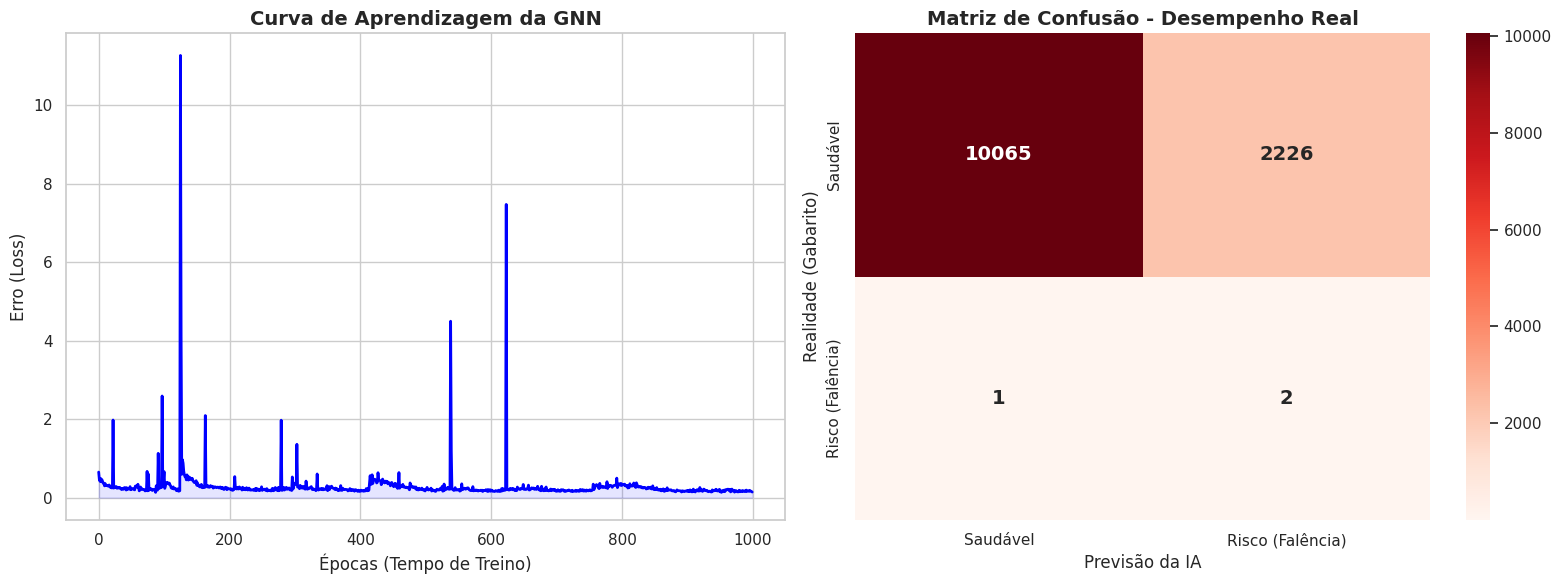

A processar a visualização da rede...


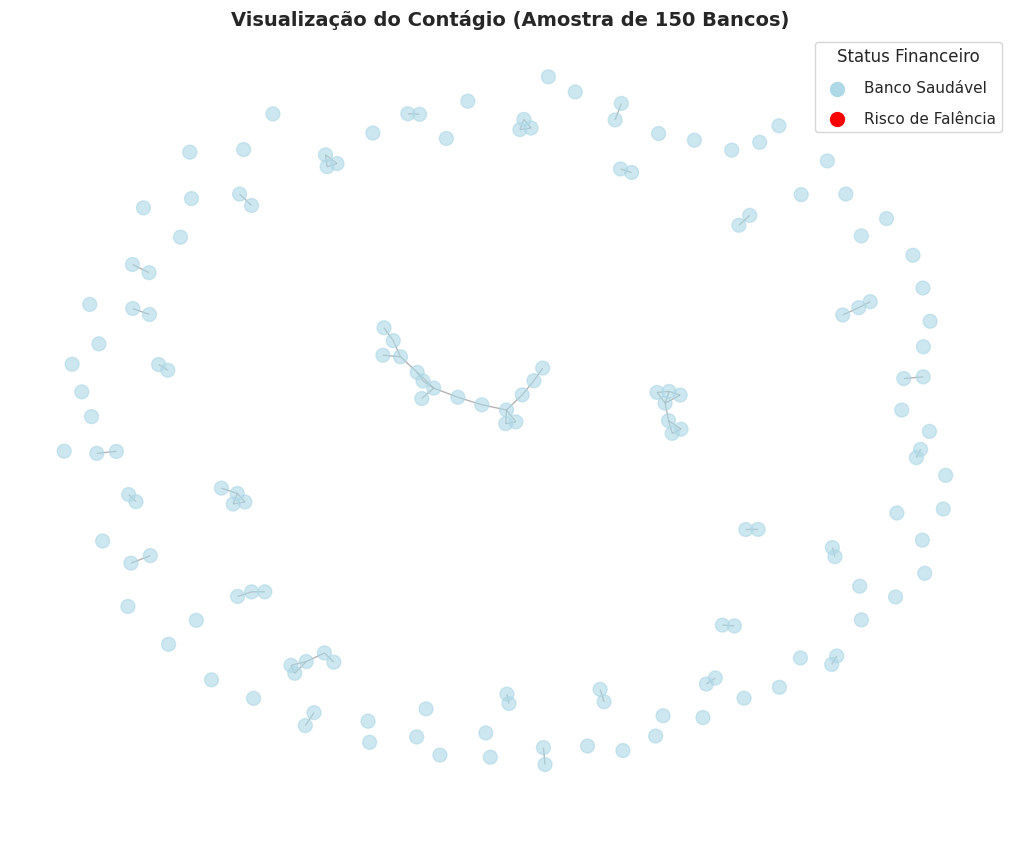

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import os

# 1. Desce e monta o Grafo
print("1. A carregar os dados para a memória...")
pasta_dados = './dados_bcb_olinda'
df_nos = pd.read_csv(os.path.join(pasta_dados, 'DATASET_FINAL_GNN.csv'), sep=';')
df_arestas = pd.read_csv(os.path.join(pasta_dados, 'EDGE_INDEX_GNN.csv'), sep=';')
colunas_ignoradas = ['Data', 'CnpjInst', 'NomeInst', 'Node_ID', 'Target_Falencia']
features = df_nos.drop(columns=[col for col in colunas_ignoradas if col in df_nos.columns])
x = torch.tensor(features.values, dtype=torch.float)
y = torch.tensor(df_nos['Target_Falencia'].values, dtype=torch.long)
source_nodes = df_arestas['Source_Node'].values
target_nodes = df_arestas['Target_Node'].values
edge_index = torch.tensor(np.vstack((source_nodes, target_nodes)), dtype=torch.long)
grafo = Data(x=x, edge_index=edge_index, y=y)
print(f"Grafo montado com sucesso! {grafo.num_nodes} bancos/trimestres e {grafo.num_edges} ligações.")
indices = np.arange(grafo.num_nodes)
treino_idx, teste_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=y.numpy())
grafo.train_mask = torch.zeros(grafo.num_nodes, dtype=torch.bool)
grafo.test_mask = torch.zeros(grafo.num_nodes, dtype=torch.bool)
grafo.train_mask[treino_idx] = True
grafo.test_mask[teste_idx] = True

# 2. Arquitetura da GNN
class SistemaAlertaAntecipadoGNN(torch.nn.Module):
    def __init__(self, num_features):
        super(SistemaAlertaAntecipadoGNN, self).__init__()
        self.conv1 = GCNConv(num_features, 64)
        self.conv2 = GCNConv(64, 32)
        self.classificador = torch.nn.Linear(32, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training) # Medida anti-overfitting
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.3, training=self.training)
        x = self.classificador(x)
        return x

modelo = SistemaAlertaAntecipadoGNN(num_features=grafo.num_node_features)

# 3. Config do weights
pesos_tensor = torch.tensor([1.0, 20000.0], dtype=torch.float)
optimizer = torch.optim.Adam(modelo.parameters(), lr=0.05, weight_decay=5e-4)
criterio = torch.nn.CrossEntropyLoss(weight=pesos_tensor)

import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from torch_geometric.utils import to_networkx

# 4. Treino
print("\n3. A iniciar o Treinamento da Rede Neuronal...")
modelo.train()
epocas = 1000
historico_loss = []

for epoca in range(epocas):
    optimizer.zero_grad()
    out = modelo(grafo.x, grafo.edge_index)
    loss = criterio(out[grafo.train_mask], grafo.y[grafo.train_mask])
    loss.backward()
    optimizer.step()
    historico_loss.append(loss.item())
    if epoca % 20 == 0:
        print(f'Época {epoca:>3} | Erro (Loss): {loss.item():.4f}')

# 5. Avaliação de desempenho
print("\n4. Treinamento Concluído. A gerar previsões...")
modelo.eval()
with torch.no_grad():
    out = modelo(grafo.x, grafo.edge_index)
    previsoes = out.argmax(dim=1)
    y_real = grafo.y[grafo.test_mask].numpy()
    y_previsto = previsoes[grafo.test_mask].numpy()

# 6. Parte dos gráficos
print("5. A gerar os gráficos visuais para o seu trabalho...")
sns.set_theme(style="whitegrid")
fig, eixos = plt.subplots(1, 2, figsize=(16, 6))

# GRÁFICO 1: Curva de Aprendizagem 
print("Gerando gráfico de curva de aprendizagem...")
eixos[0].plot(historico_loss, color='blue', linewidth=2)
eixos[0].set_title('Curva de Aprendizagem da GNN', fontsize=14, fontweight='bold')
eixos[0].set_xlabel('Épocas (Tempo de Treino)', fontsize=12)
eixos[0].set_ylabel('Erro (Loss)', fontsize=12)
eixos[0].fill_between(range(len(historico_loss)), historico_loss, alpha=0.1, color='blue')

# GRÁFICO 2: Heatmap da Matriz de Confusão
print("Gerando gráfico de matriz de confusão...")
cm = confusion_matrix(y_real, y_previsto)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=eixos[1], 
            xticklabels=['Saudável', 'Risco (Falência)'], 
            yticklabels=['Saudável', 'Risco (Falência)'],
            annot_kws={"size": 14, "weight": "bold"})
eixos[1].set_title('Matriz de Confusão - Desempenho Real', fontsize=14, fontweight='bold')
eixos[1].set_xlabel('Previsão da IA', fontsize=12)
eixos[1].set_ylabel('Realidade (Gabarito)', fontsize=12)

plt.tight_layout()
plt.show() 

from torch_geometric.utils import to_networkx, subgraph
import torch
import networkx as nx
import matplotlib.pyplot as plt

# GRÁFICO 3: Visualização do Grafo (Amostra Segura)
print("A processar a visualização da rede...")
subset = torch.arange(150)
sub_edge_index, _ = subgraph(subset, grafo.edge_index, relabel_nodes=True)
grafo_amostra = Data(x=grafo.x[:150], edge_index=sub_edge_index)
G = to_networkx(grafo_amostra, to_undirected=True)
cores = ['red' if target == 1 else 'lightblue' for target in grafo.y[:150].numpy()]
plt.figure(figsize=(10, 8))
posicoes = nx.spring_layout(G, seed=42)
nx.draw(G, posicoes, node_color=cores, node_size=100, edge_color='gray', alpha=0.6, with_labels=False)
plt.scatter([], [], c='lightblue', label='Banco Saudável', s=100)
plt.scatter([], [], c='red', label='Risco de Falência', s=100)
plt.legend(scatterpoints=1, frameon=True, labelspacing=1, title="Status Financeiro")
plt.title('Visualização do Contágio (Amostra de 150 Bancos)', fontsize=14, fontweight='bold')
plt.show()

A processar a visualização da rede densa de contágio (Todos os Nós Falidos)...
Encontrados 14 nós de bancos falidos. Expandindo vizinhança...
Subgrafo extraído: 4481 nós e 21398 conexões. Gerando layout...
Gerando layout do gráfico denso...
Desenhando nós com bordas definidas...


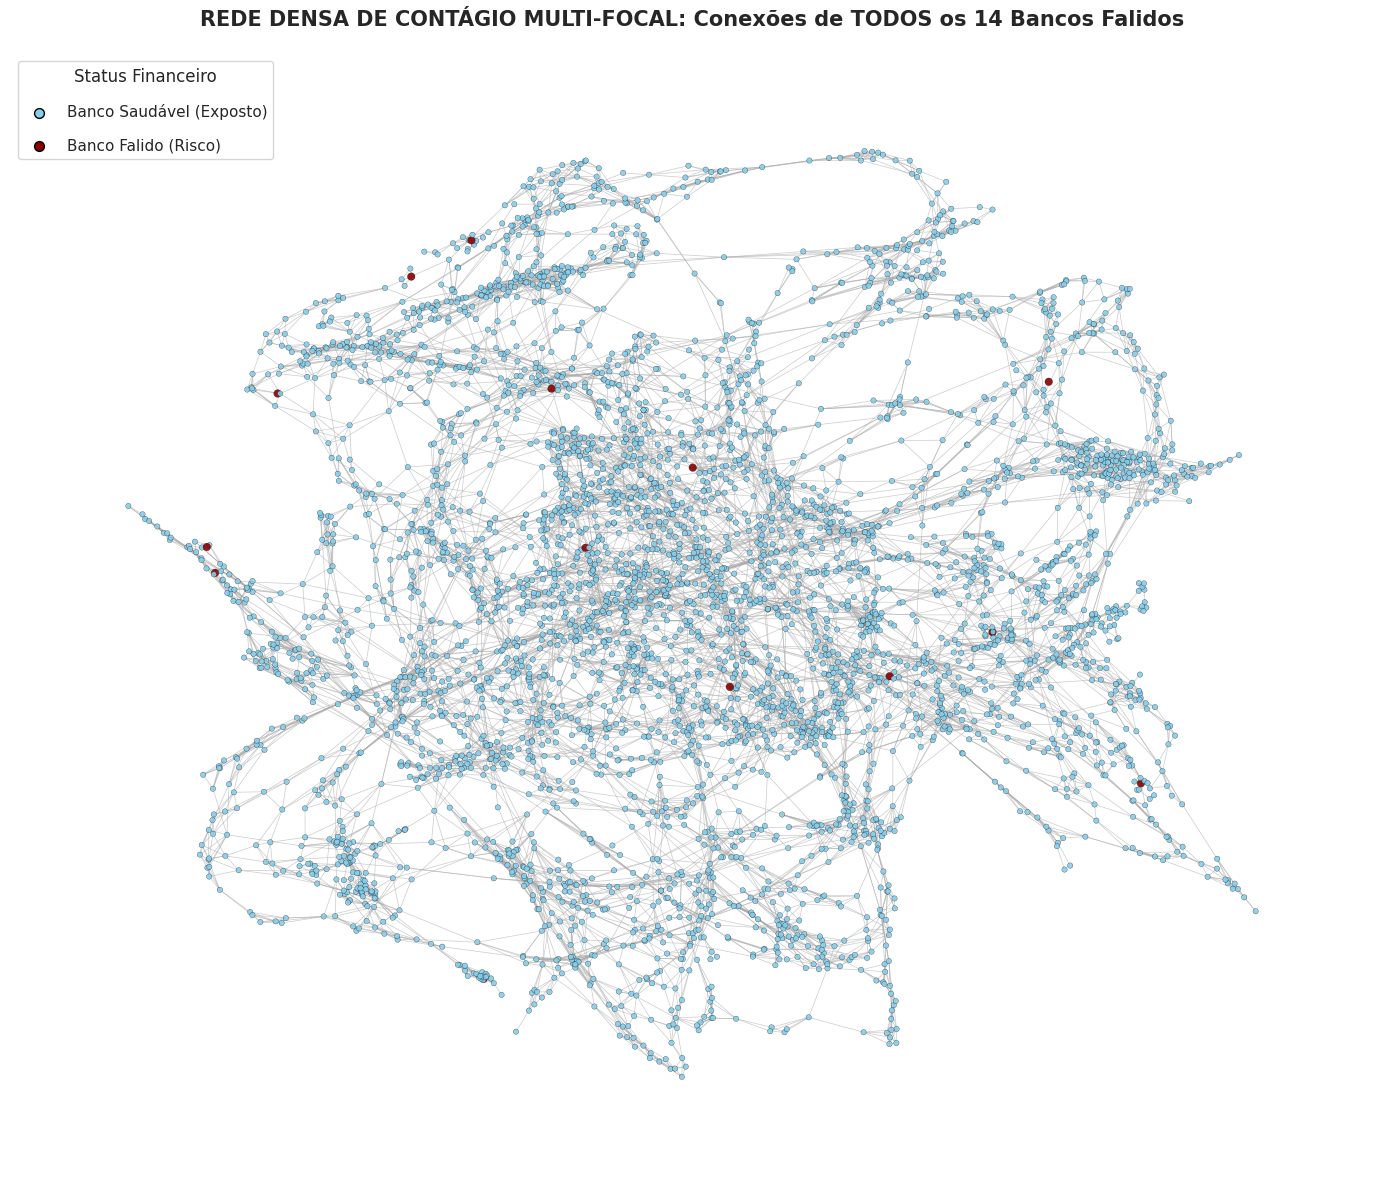

In [25]:
from torch_geometric.utils import k_hop_subgraph
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

# GRÁFICO 3: Visualização do Contágio Denso (Multi-focal) com Destaque nos Nós
print("A processar a visualização da rede densa de contágio (Todos os Nós Falidos)...")

# 1. Encontrar os índices de TODOS os bancos que faliram (y == 1)
indices_falencia = torch.where(grafo.y == 1)[0].tolist()

if len(indices_falencia) > 0:
    print(f"Encontrados {len(indices_falencia)} nós de bancos falidos. Expandindo vizinhança...")
    
    # 2. PUXAR A REDE DENSA: 2 saltos (hops) partindo de TODOS os falidos ao mesmo tempo
    # Isso expande para vizinhos de vizinhos, gerando densidade sistêmica.
    subset, sub_edge_index, _, _ = k_hop_subgraph(
        node_idx=indices_falencia, # A lista inteira de falidos!
        num_hops=25, 
        edge_index=grafo.edge_index, 
        relabel_nodes=True
    )
    
    print(f"Subgrafo extraído: {len(subset)} nós e {sub_edge_index.shape[1]} conexões. Gerando layout...")

    # Montar o sub-grafo denso para visualização
    grafo_amostra = Data(x=grafo.x[subset], edge_index=sub_edge_index)
    G = to_networkx(grafo_amostra, to_undirected=True)
    
    # 3. Estilização para Contraste e Densidade
    cores = []
    tamanhos = []
    
    for i, no_original in enumerate(subset):
        if grafo.y[no_original].item() == 1:
            cores.append('darkred')  # Nós dos bancos falidos (Risco)
            tamanhos.append(30)     # Destaque visual (aumentei um pouco)
        else:
            cores.append('skyblue')  # Bancos saudáveis expostos (Azul Claro)
            tamanhos.append(15)      # Pequenos
            
    # 4. Desenhar o grafo (pode demorar um pouco devido à densidade)
    plt.figure(figsize=(14, 12)) # Canvas grande para ver a densidade
    
    # O layout Fruchterman-Reingold funciona bem para ver clusters e densidade
    print("Gerando layout do gráfico denso...")
    posicoes = nx.fruchterman_reingold_layout(G, seed=42, k=0.1) 
    
    # Desenhar as arestas (linhas de conexão) - Visíveis e cinzas (darkgray)
    nx.draw_networkx_edges(G, posicoes, edge_color='darkgray', alpha=0.6, width=0.5)
    
    # ==========================================
    # O SEGREDO ESTÁ AQUI: Nós com Borda Preta!
    # Adicionámos edgecolors='black' e linewidths=1.0
    # ==========================================
    print("Desenhando nós com bordas definidas...")
    nx.draw_networkx_nodes(G, posicoes, 
                           node_color=cores, 
                           node_size=tamanhos, 
                           alpha=0.9, 
                           edgecolors='black', # Borda Preta
                           linewidths=0.2)     # Espessura da borda

    # Configurar legendas customizadas com a estilização correta
    plt.scatter([], [], c='skyblue', label='Banco Saudável (Exposto)', s=50, edgecolors='black')
    plt.scatter([], [], c='darkred', label='Banco Falido (Risco)', s=50, edgecolors='black')
    
    plt.legend(scatterpoints=1, frameon=True, labelspacing=1.2, title="Status Financeiro", loc='upper left', fontsize=11)
    
    plt.title(f'REDE DENSA DE CONTÁGIO MULTI-FOCAL: Conexões de TODOS os {len(indices_falencia)} Bancos Falidos', 
              fontsize=15, fontweight='bold', pad=20)
    
    # Limpeza final do gráfico
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Nenhuma falência encontrada no dataset para visualizar.")